In [3]:
# Mount Drive (if using Google Colab)
from google.colab import drive
drive.mount('/content/gdrive')

# Import necessary libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

Mounted at /content/gdrive


Folder: def_front


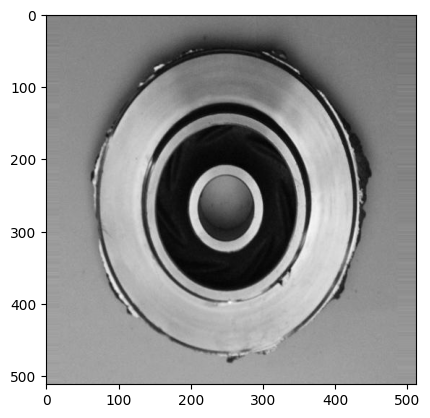

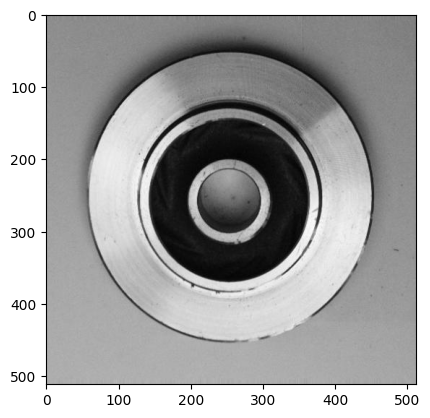

Folder: ok_front


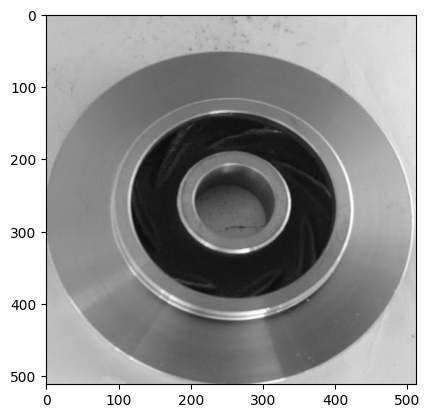

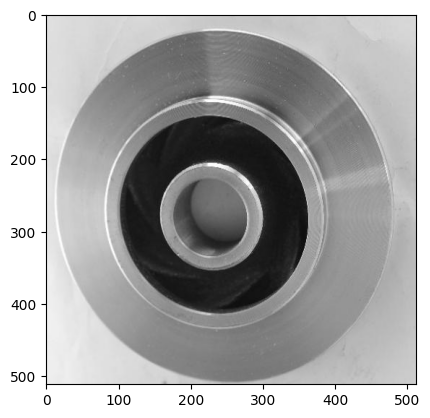

In [ ]:
# Define paths to datasets
train_path = '/content/gdrive/MyDrive/Colab Notebooks/project_dataset/Train'
test_path = '/content/gdrive/MyDrive/Colab Notebooks/project_dataset/Test'
val_path = '/content/gdrive/MyDrive/Colab Notebooks/project_dataset/Valid'

# Preview a couple of images
for folder in os.listdir(train_path):
    sub_path = os.path.join(train_path, folder)
    print(f"Folder: {folder}")
    for i in range(2):
        temp_path = os.path.join(sub_path, os.listdir(sub_path)[i])
        img = mpimg.imread(temp_path)
        plt.imshow(img)
        plt.show()

In [ ]:
# Mount Drive (if using Google Colab)
from google.colab import drive
drive.mount('/content/gdrive')

# Import necessary libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

# Define dataset paths
train_path = '/content/gdrive/MyDrive/Colab Notebooks/project_dataset/Train'
test_path = '/content/gdrive/MyDrive/Colab Notebooks/project_dataset/Test'
val_path = '/content/gdrive/MyDrive/Colab Notebooks/project_dataset/Valid'

# Function to load images and labels
def imagearray(path, size):
    data = []
    labels = []
    class_names = sorted(os.listdir(path))  # Get class labels
    for label, sub_folder in enumerate(class_names):  # Assign numeric labels
        sub_path = os.path.join(path, sub_folder)
        for img in os.listdir(sub_path):
            image_path = os.path.join(sub_path, img)
            img_arr = cv2.imread(image_path)
            if img_arr is None:
                print(f"Skipping unreadable image: {image_path}")
                continue  # Skip corrupt images
            img_arr = cv2.resize(img_arr, size)
            data.append(img_arr)
            labels.append(label)  # Store class label
    return np.array(data), np.array(labels)  # Return images + labels

# Set image size
size = (250, 250)

# Load images and labels
x_train, y_train = imagearray(train_path, size)
x_test, y_test = imagearray(test_path, size)
x_val, y_val = imagearray(val_path, size)

# Normalize images
x_train, x_test, x_val = x_train / 255.0, x_test / 255.0, x_val / 255.0

# Convert labels to one-hot encoding
num_classes = len(set(y_train))  # Get number of classes
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
y_val = to_categorical(y_val, num_classes)

# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Load Pretrained VGG19 Model (without top layers)
base_model = VGG19(weights='imagenet', include_top=False,
input_shape=(250, 250, 3))

# Freeze most layers (except last 4)
for layer in base_model.layers[:-4]:
    layer.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Build the model
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),  # Dropout to reduce overfitting
    Dense(256, activation='relu'),
    BatchNormalization(),  # Batch Norm to stabilize learning
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')  # Adjust output layer based on dataset
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy',
metrics=['accuracy'])

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5,
restore_best_weights=True)


In [ ]:
# Train the model
history = model.fit(
    train_datagen.flow(x_train, y_train, batch_size=32),
    validation_data=test_datagen.flow(x_val, y_val, batch_size=32),
    epochs=50,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5508 - loss: 1.5730 - val_accuracy: 0.6040 - val_loss: 3.0528
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 596ms/step - accuracy: 0.5946 - loss: 1.1884 - val_accuracy: 0.3960 - val_loss: 1.4084
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 608ms/step - accuracy: 0.7276 - loss: 0.8842 - val_accuracy: 0.6560 - val_loss: 0.8950
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 606ms/step - accuracy: 0.7995 - loss: 0.6917 - val_accuracy: 0.6040 - val_loss: 0.9711
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 600ms/step - accuracy: 0.8791 - loss: 0.5433 - val_accuracy: 0.8880 - val_loss: 0.4746
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 583ms/step - accuracy: 0.8969 - loss: 0.4668 - val_accuracy: 0.7440 - val_loss: 0.8532
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 20s 603ms/step - accuracy: 0.8633 - loss: 0.5096 - val_accuracy: 0.6120 - val_loss: 1.8291
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 588ms/step - accuracy: 0.8857 - loss: 0.4155 - val_accurac

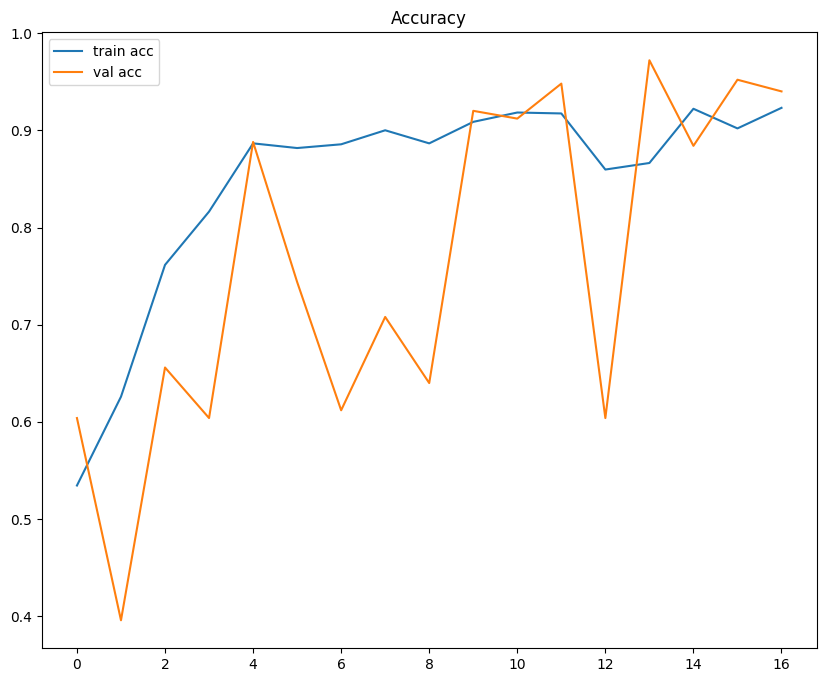

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')
plt.show()

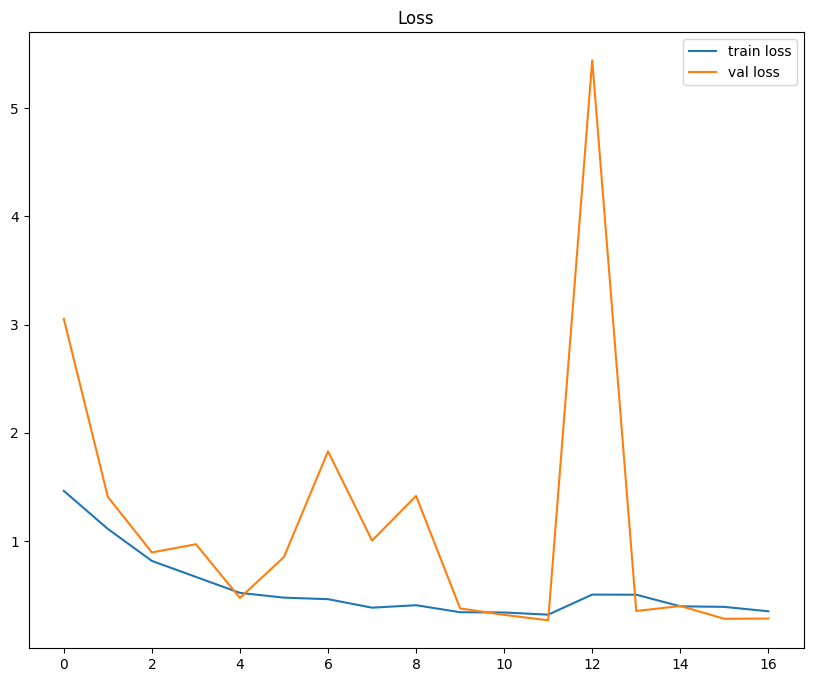

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')
plt.show()

In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_datagen.flow(x_test, y_test, batch_size=32))
print(f"Test Accuracy: {test_acc * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - accuracy: 0.9483 - loss: 0.2748
Test Accuracy: 94.80%


8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 373ms/step


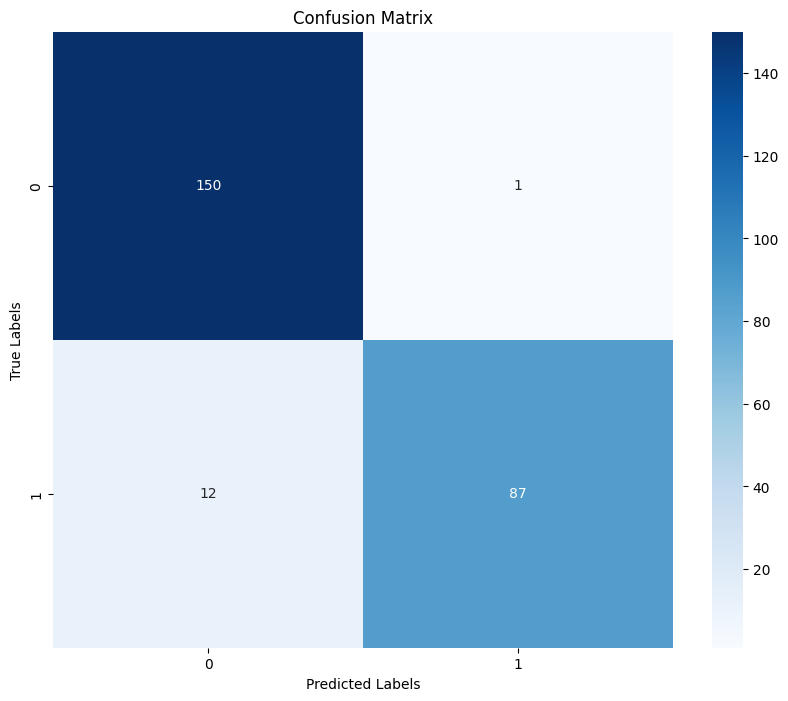

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       151
           1       0.99      0.88      0.93        99

    accuracy                           0.95       250
   macro avg       0.96      0.94      0.94       250
weighted avg       0.95      0.95      0.95       250



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Get model predictions on the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot labels back to class indices

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))


In [1]:
# Save the entire model (architecture + weights + optimizer state)
model.save('/content/gdrive/MyDrive/vgg19_FinalModel.h5')

print("Model saved successfully!")

NameError: name 'model' is not defined

In [ ]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('/content/gdrive/MyDrive/vgg19_FinalModel.h5')

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the model
model_path = "/content/drive/MyDrive/vgg19_FinalModel.h5"  # Update the path
model = torch.load(model_path)
model.eval()

# Load test data (replace with actual test data)
X_test = np.load("/content/drive/MyDrive/Colab Notebooks/project_dataset/Test")  # Example test features
y_test = np.load("/content/drive/MyDrive/Colab Notebooks/project_dataset/Test")  # Example test labels

# Convert to PyTorch tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# Get model predictions
with torch.no_grad():
    y_pred_probs = model(X_test_tensor).numpy()

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot AUC-ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC-ROC Curve')
plt.legend(loc='lower right')
plt.show()
